In [19]:

from pathlib import Path
import torch



### Setup save directory to save the data 

In [20]:

# ============================================================
# Model save directory
# ============================================================

SAVE_DIR = Path("models/24_lookback_24_horizon_syn")

SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = SAVE_DIR / "best_lstm.pt"

### Load data and validate the data 

In [21]:
from src.dataloader import LoadForecastDataLoader

loader = LoadForecastDataLoader(

    csv_path="Data/synthetic_ireland_national_hourly.csv",

    datetime_col="timestamp_local",
    # datetime_format="%Y-%m-%dT%H:%M:%S%z", # define a datetime format if the datetime column is not in a standard format
    features=[
        "hour", "day_of_week", "month",
        "mean_wind_speed", "wind_capacity_weighted_wind_speed","wind_speed_squared","wind_speed_lag_1h",
        "mean_temperature","temperature_lag_1h",
    ],

    target="wind_generation_mw",

    lookback=48,

    horizon=24,

    expected_frequency="1h"
)

In [22]:
df_all = loader.get_dataframe()

In [23]:
df_all

,timestamp_local,timestamp_utc,hour,day_of_week,month,weekend_flag,season,daylight_flag,mean_temperature,population_weighted_temperature,...,wind_generation_mw,solar_generation_mw,gas_generation_mw,other_generation_mw,renewable_generation_mw,renewable_generation_percentage,net_exports_mw,consumption_lag_1h,consumption_lag_24h,random_control
0,2022-01-01 00:00:00+00:00,2022-01-01T00:00:00+00:00,0,5,1,1,winter,0,1.28,1.19,...,1346.9,0.0,2071.1,567.5,1346.9,33.80,20.8,4396.2,4061.7,-0.51891
1,2022-01-01 01:00:00+00:00,2022-01-01T01:00:00+00:00,1,5,1,1,winter,0,1.64,1.57,...,1553.2,0.0,1593.1,571.1,1553.2,41.78,41.3,3964.7,4049.0,-0.21422
2,2022-01-01 02:00:00+00:00,2022-01-01T02:00:00+00:00,2,5,1,1,winter,0,0.57,0.46,...,1436.1,0.0,1732.7,576.8,1436.1,38.34,-15.3,3676.1,3926.0,0.46331
3,2022-01-01 03:00:00+00:00,2022-01-01T03:00:00+00:00,3,5,1,1,winter,0,0.15,-0.02,...,2370.6,0.0,882.2,589.2,2370.6,61.70,128.6,3760.9,3887.3,-0.14404
4,2022-01-01 04:00:00+00:00,2022-01-01T04:00:00+00:00,4,5,1,1,winter,0,-0.08,-0.28,...,1655.3,0.0,1666.3,613.4,1655.3,42.07,102.1,3713.4,4013.0,-0.44085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2024-12-31 19:00:00+00:00,2024-12-31T19:00:00+00:00,19,1,12,0,winter,0,9.42,9.72,...,1419.9,0.0,2452.2,587.7,1419.9,31.84,29.3,4526.7,4583.9,0.54431
26300,2024-12-31 20:00:00+00:00,2024-12-31T20:00:00+00:00,20,1,12,0,winter,0,8.83,9.16,...,969.6,0.0,2504.7,619.6,969.6,23.68,-135.2,4430.5,4409.9,1.29025
26301,2024-12-31 21:00:00+00:00,2024-12-31T21:00:00+00:00,21,1,12,0,winter,0,8.99,9.20,...,846.6,0.0,2606.5,623.6,846.6,20.77,-89.6,4229.1,4164.1,-1.05788
26302,2024-12-31 22:00:00+00:00,2024-12-31T22:00:00+00:00,22,1,12,0,winter,0,8.92,9.16,...,686.6,0.0,2466.4,633.0,686.6,18.14,-159.3,4166.3,4042.7,-1.01784


### seperate the data [Not necessay but done here just to test]

In [24]:
start_date = "2022-01-01"
end_date = "2023-03-31"

df = df_all[
    (df_all["timestamp_local"] >= start_date) &
    (df_all["timestamp_local"] <= end_date)
]

In [25]:
loader.summary()


DATASET SUMMARY
File:       Data\synthetic_ireland_national_hourly.csv
Rows:       26304
Columns:    34
Datetime:   timestamp_local
Features:   ['hour', 'day_of_week', 'month', 'mean_wind_speed', 'wind_capacity_weighted_wind_speed', 'wind_speed_squared', 'wind_speed_lag_1h', 'mean_temperature', 'temperature_lag_1h']
Target:     ['wind_generation_mw']
Lookback:   48
Horizon:    24
Frequency:  1h
Start:      2022-01-01 00:00:00+00:00
End:        2024-12-31 23:00:00+00:00

Abnormalities:
- numeric_abnormalities: {'mean_temperature': {'negative_values': 29}, 'temperature_lag_1h': {'negative_values': 26}}



In [26]:
df

,timestamp_local,timestamp_utc,hour,day_of_week,month,weekend_flag,season,daylight_flag,mean_temperature,population_weighted_temperature,...,wind_generation_mw,solar_generation_mw,gas_generation_mw,other_generation_mw,renewable_generation_mw,renewable_generation_percentage,net_exports_mw,consumption_lag_1h,consumption_lag_24h,random_control
0,2022-01-01 00:00:00+00:00,2022-01-01T00:00:00+00:00,0,5,1,1,winter,0,1.28,1.19,...,1346.9,0.0,2071.1,567.5,1346.9,33.80,20.8,4396.2,4061.7,-0.51891
1,2022-01-01 01:00:00+00:00,2022-01-01T01:00:00+00:00,1,5,1,1,winter,0,1.64,1.57,...,1553.2,0.0,1593.1,571.1,1553.2,41.78,41.3,3964.7,4049.0,-0.21422
2,2022-01-01 02:00:00+00:00,2022-01-01T02:00:00+00:00,2,5,1,1,winter,0,0.57,0.46,...,1436.1,0.0,1732.7,576.8,1436.1,38.34,-15.3,3676.1,3926.0,0.46331
3,2022-01-01 03:00:00+00:00,2022-01-01T03:00:00+00:00,3,5,1,1,winter,0,0.15,-0.02,...,2370.6,0.0,882.2,589.2,2370.6,61.70,128.6,3760.9,3887.3,-0.14404
4,2022-01-01 04:00:00+00:00,2022-01-01T04:00:00+00:00,4,5,1,1,winter,0,-0.08,-0.28,...,1655.3,0.0,1666.3,613.4,1655.3,42.07,102.1,3713.4,4013.0,-0.44085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10892,2023-03-30 20:00:00+00:00,2023-03-30T20:00:00+00:00,21,3,3,0,spring,0,10.59,10.57,...,1173.5,0.0,2252.3,551.4,1173.5,29.51,-84.4,4311.2,3885.9,-1.33274
10893,2023-03-30 21:00:00+00:00,2023-03-30T21:00:00+00:00,22,3,3,0,spring,0,10.14,10.05,...,1044.4,0.0,2175.0,551.8,1044.4,27.69,-126.1,4061.6,3621.3,0.84834
10894,2023-03-30 22:00:00+00:00,2023-03-30T22:00:00+00:00,23,3,3,0,spring,0,9.83,9.82,...,1224.8,0.0,2035.6,554.6,1224.8,32.10,0.5,3897.3,3482.8,-0.02053
10895,2023-03-30 23:00:00+00:00,2023-03-30T23:00:00+00:00,0,4,3,0,spring,0,9.50,9.53,...,1147.5,0.0,1885.8,534.5,1147.5,32.16,-3.6,3814.5,3207.9,1.21485


### Train, Test and Validation data set seperation

In [27]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

### Data normalization [Scaling]

In [28]:
from sklearn.preprocessing import StandardScaler


features = loader.features
target = loader.target


feature_scaler = StandardScaler()
target_scaler = StandardScaler()


# Fit ONLY on training data
feature_scaler.fit(
    train_df[features]
)

target_scaler.fit(
    train_df[target]
)


# Transform all datasets
train_features = feature_scaler.transform(
    train_df[features]
)

val_features = feature_scaler.transform(
    val_df[features]
)

test_features = feature_scaler.transform(
    test_df[features]
)


train_target = target_scaler.transform(
    train_df[target]
)

val_target = target_scaler.transform(
    val_df[target]
)

test_target = target_scaler.transform(
    test_df[target]
)

### Preperaing data for lstm model lookback [t-n we plan to use as look back], horizon [t -> t+n we plan to forecast]

In [29]:
from src.models.lstm import LSTMDataset
# setup dataset to train 
train_dataset = LSTMDataset(
    train_features,
    train_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

val_dataset = LSTMDataset(
    val_features,
    val_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

test_dataset = LSTMDataset(
    test_features,
    test_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

### Dataload, help load the data for train and testing 
Batch size define the size of data we plan to feed in on go, and shuffle -[True refer to randominzing data false result to sequential feeding]

In [30]:
from torch.utils.data import DataLoader


BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

###### Checking how the data is generated

In [31]:
X, y = next(iter(train_loader))

print("X:", X.shape)
print("y:", y.shape)

X: torch.Size([64, 48, 9])
y: torch.Size([64, 24, 1])


In [32]:
X

tensor([[[ 0.0732, -1.0006, -1.5769,  ...,  0.4837, -0.6401, -0.8643],
         [ 0.2177, -1.0006, -1.5769,  ...,  0.7397, -0.7478, -0.6738],
         [ 0.3622, -1.0006, -1.5769,  ...,  0.4569, -0.9093, -0.7544],
         ...,
         [-0.3604, -0.0041, -1.5769,  ...,  1.3511, -1.6785, -1.6623],
         [-0.2159, -0.0041, -1.5769,  ...,  0.9499, -1.7144, -1.6959],
         [-0.0714, -0.0041, -1.5769,  ...,  0.9881, -1.5955, -1.7273]],

        [[-1.0829, -1.4989, -0.2531,  ..., -0.8385,  0.7728,  0.7205],
         [-0.9384, -1.4989, -0.2531,  ..., -0.7965,  0.7503,  0.7631],
         [-0.7939, -1.4989, -0.2531,  ..., -1.0601,  0.8961,  0.7272],
         ...,
         [-1.5164, -0.5024,  0.0778,  ..., -1.3429,  0.5619,  0.6555],
         [-1.3719, -0.5024,  0.0778,  ..., -1.0257,  0.5238,  0.5524],
         [-1.2274, -0.5024,  0.0778,  ..., -1.0028,  0.4453,  0.5300]],

        [[-1.3719, -1.4989,  1.0707,  ..., -0.7315,  0.4700,  0.4806],
         [-1.2274, -1.4989,  1.0707,  ..., -1

### Setting up LSTM model, LSTMForecast help to setup a model

In [33]:
from src.models.lstm import LSTMForecast
from torch import nn

INPUT_SIZE = len(loader.features)

model = LSTMForecast(
    input_size=INPUT_SIZE,
    hidden_size=64,
    num_layers=2,
    horizon=loader.horizon,
    dropout=0.2
)   # loading model 

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
) # setting up device GPU or CPU for training

model = model.to(device) # the setup model to device GPU or CPU for training

print(device)

criterion = nn.MSELoss() # training loss function for regression tasks

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
) # optimizer for training the model, using Adam optimization algorithm with a learning rate of 0.001

cpu


### Training and Validation funtion for single step

In [34]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    for X, y in dataloader:

        X = X.to(device)
        y = y.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        prediction = model(X)

        # Calculate loss
        loss = criterion(
            prediction,
            y
        )

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()

        total_loss += loss.item()

    return (
        total_loss / len(dataloader)
    )

In [35]:
def validate(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for X, y in dataloader:

            X = X.to(device)
            y = y.to(device)

            prediction = model(X)

            loss = criterion(
                prediction,
                y
            )

            total_loss += loss.item()

    return (
        total_loss / len(dataloader)
    )

### Traning the model an saving

In [36]:

EPOCHS = 50

best_val_loss = float("inf")

train_losses = []
val_losses = []


for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} "
        f"| Train: {train_loss:.5f} "
        f"| Val: {val_loss:.5f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"  -> Best model saved to: "
            f"{BEST_MODEL_PATH}"
        )

Epoch 01/50 | Train: 0.73449 | Val: 0.95259
  -> Best model saved to: models\24_lookback_24_horizon_syn\best_lstm.pt
Epoch 02/50 | Train: 0.63308 | Val: 0.95138
  -> Best model saved to: models\24_lookback_24_horizon_syn\best_lstm.pt
Epoch 03/50 | Train: 0.60627 | Val: 1.01713
Epoch 04/50 | Train: 0.57434 | Val: 1.08076
Epoch 05/50 | Train: 0.54269 | Val: 1.15396
Epoch 06/50 | Train: 0.50714 | Val: 1.12204
Epoch 07/50 | Train: 0.45577 | Val: 1.22369
Epoch 08/50 | Train: 0.38201 | Val: 1.20422
Epoch 09/50 | Train: 0.34341 | Val: 1.31554
Epoch 10/50 | Train: 0.29926 | Val: 1.32707
Epoch 11/50 | Train: 0.28316 | Val: 1.35113
Epoch 12/50 | Train: 0.24919 | Val: 1.37621
Epoch 13/50 | Train: 0.23731 | Val: 1.40127
Epoch 14/50 | Train: 0.24047 | Val: 1.43195
Epoch 15/50 | Train: 0.19769 | Val: 1.41681
Epoch 16/50 | Train: 0.18083 | Val: 1.47258
Epoch 17/50 | Train: 0.17072 | Val: 1.48446
Epoch 18/50 | Train: 0.16496 | Val: 1.48146
Epoch 19/50 | Train: 0.15228 | Val: 1.49230
Epoch 20/50 | Trai

### Loading model

In [37]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

LSTMForecast(
  (lstm): LSTM(9, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=24, bias=True)
)

### Testing the model

In [38]:
import numpy as np


predictions = []
actuals = []


with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)

        prediction = model(X)

        predictions.append(
            prediction.cpu().numpy()
        )

        actuals.append(
            y.numpy()
        )


predictions = np.concatenate(
    predictions,
    axis=0
)

actuals = np.concatenate(
    actuals,
    axis=0
)

print(
    "Predictions:",
    predictions.shape
)

print(
    "Actual:",
    actuals.shape
)

Predictions: (1564, 24, 1)
Actual: (1564, 24, 1)


### Coverting the data back to original 
As to train the model we Scale them using mean and std 

In [39]:
predictions_original = (
    target_scaler
    .inverse_transform(
        predictions.reshape(-1, 1)
    )
    .reshape(predictions.shape)
)

actuals_original = (
    target_scaler
    .inverse_transform(
        actuals.reshape(-1, 1)
    )
    .reshape(actuals.shape)
)

#### evaluating the results with MAE and RMSE

In [40]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


mae = mean_absolute_error(
    actuals_original.flatten(),
    predictions_original.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        actuals_original.flatten(),
        predictions_original.flatten()
    )
)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  632.99
RMSE: 783.64


Pred shape: (37536,)
Act shape: (37536,)


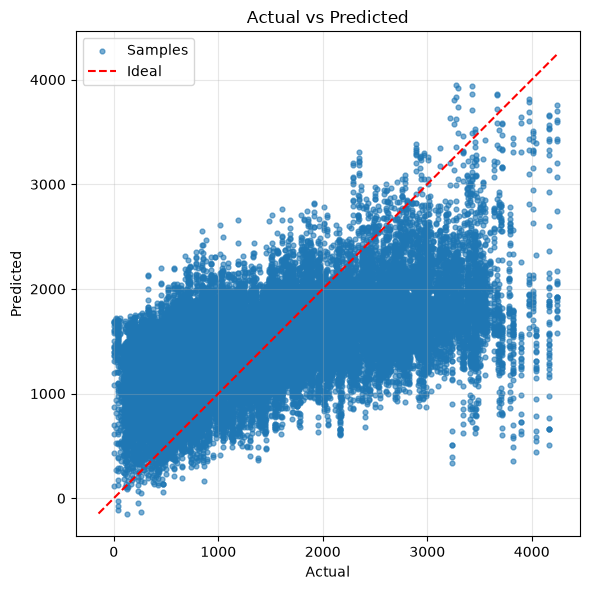

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# --- ensure shapes are compatible ---
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

print("Pred shape:", pred.shape)
print("Act shape:", act.shape)

# --- scatter plot ---
plt.figure(figsize=(6,6))
plt.scatter(act, pred, s=12, alpha=0.6, label="Samples")

# --- 1:1 reference line ---
min_v = min(act.min(), pred.min())
max_v = max(act.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


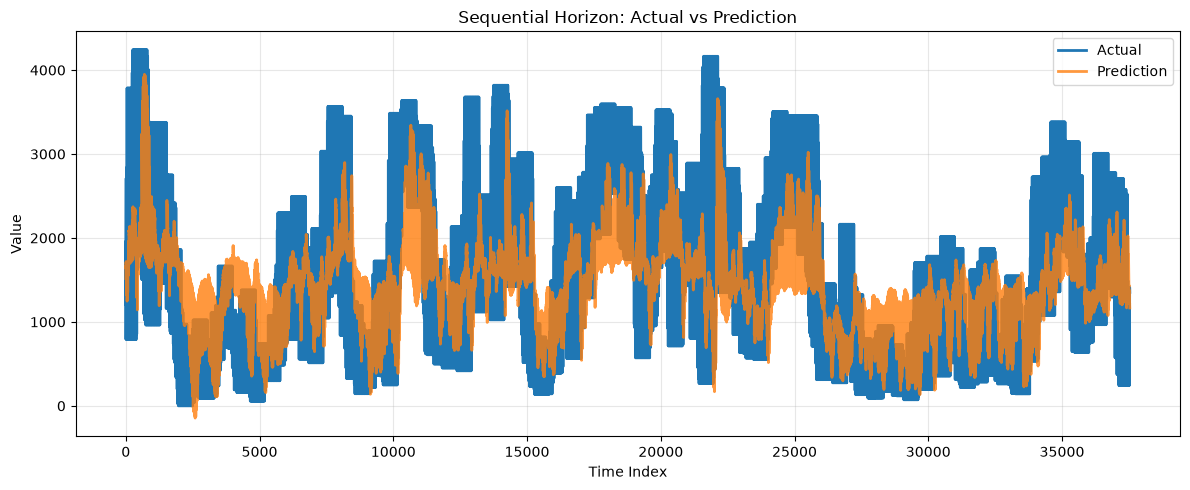

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten in case they are (N,1)
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

# Create a time index
t = np.arange(len(pred))

plt.figure(figsize=(12,5))
plt.plot(t, act, label="Actual", linewidth=2)
plt.plot(t, pred, label="Prediction", linewidth=2, alpha=0.8)

plt.title("Sequential Horizon: Actual vs Prediction")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


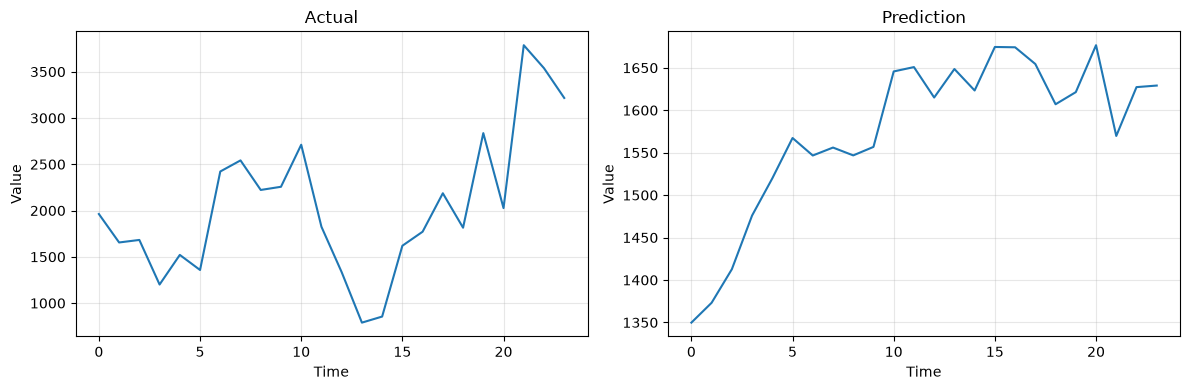

In [43]:
import matplotlib.pyplot as plt

# Select sample index
i = 3

actual = actuals_original[i, :, :]
pred   = predictions_original[i, :, :]

plt.figure(figsize=(12,4))

# --- Actual ---
plt.subplot(1, 2, 1)
plt.plot(actual)
plt.title("Actual")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)

# --- Prediction ---
plt.subplot(1, 2, 2)
plt.plot(pred)
plt.title("Prediction")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


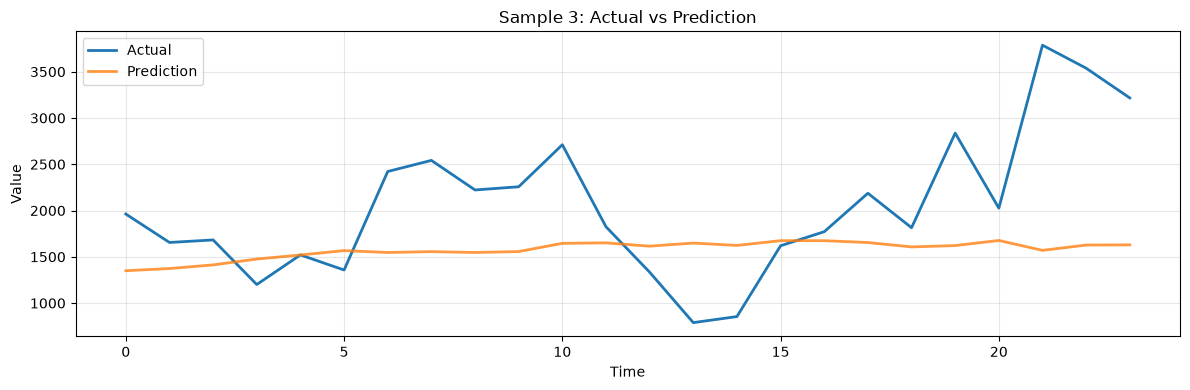

In [44]:
# Select sample index
i = 3

actual = actuals_original[i, :, :]
pred   = predictions_original[i, :, :]

plt.figure(figsize=(12,4))

plt.plot(actual, label="Actual", linewidth=2)
plt.plot(pred, label="Prediction", linewidth=2, alpha=0.8)

plt.title(f"Sample {i}: Actual vs Prediction")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()
